# Visualise cells

In [6]:
import matplotlib.pyplot as plt
from locpix_points.preprocessing import datastruc

import os
import numpy as np
import pandas as pd
import polars as pl

## Parameters

In [7]:
# Preprocessing
input_folder = "../cells/gt_label"
files = os.listdir(input_folder)

## ++++ Can run rest of notebook without changing ++++

## Define functions

In [8]:
def plot_cell(df, ax, label=None, best_r=None):
    ax.tick_params(left = False, labelleft=False, bottom = False, labelbottom=False)
    ax.set(aspect=1)
    ax.scatter(df[["x"]], df[["y"]], c='k', s=10)
    ax.ticklabel_format(style="sci", scilimits=[0,0])
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(6)

    if best_r is not None:
        if best_r == 1:
            for axis in ['top','bottom','left','right']:
                ax.spines[axis].set_color('r')
        elif best_r == 2:
            for axis in ['top','bottom','left','right']:
                ax.spines[axis].set_color('g')
        elif best_r == 4:
            for axis in ['top','bottom','left','right']:
                ax.spines[axis].set_color('b')
        elif best_r == 6:
            for axis in ['top','bottom','left','right']:
                ax.spines[axis].set_color('y')
        elif best_r == 9:
            for axis in ['top','bottom','left','right']:
                ax.spines[axis].set_color('m')
        else:
            raise ValueError("best r is not in the list")

## Visualise all cells

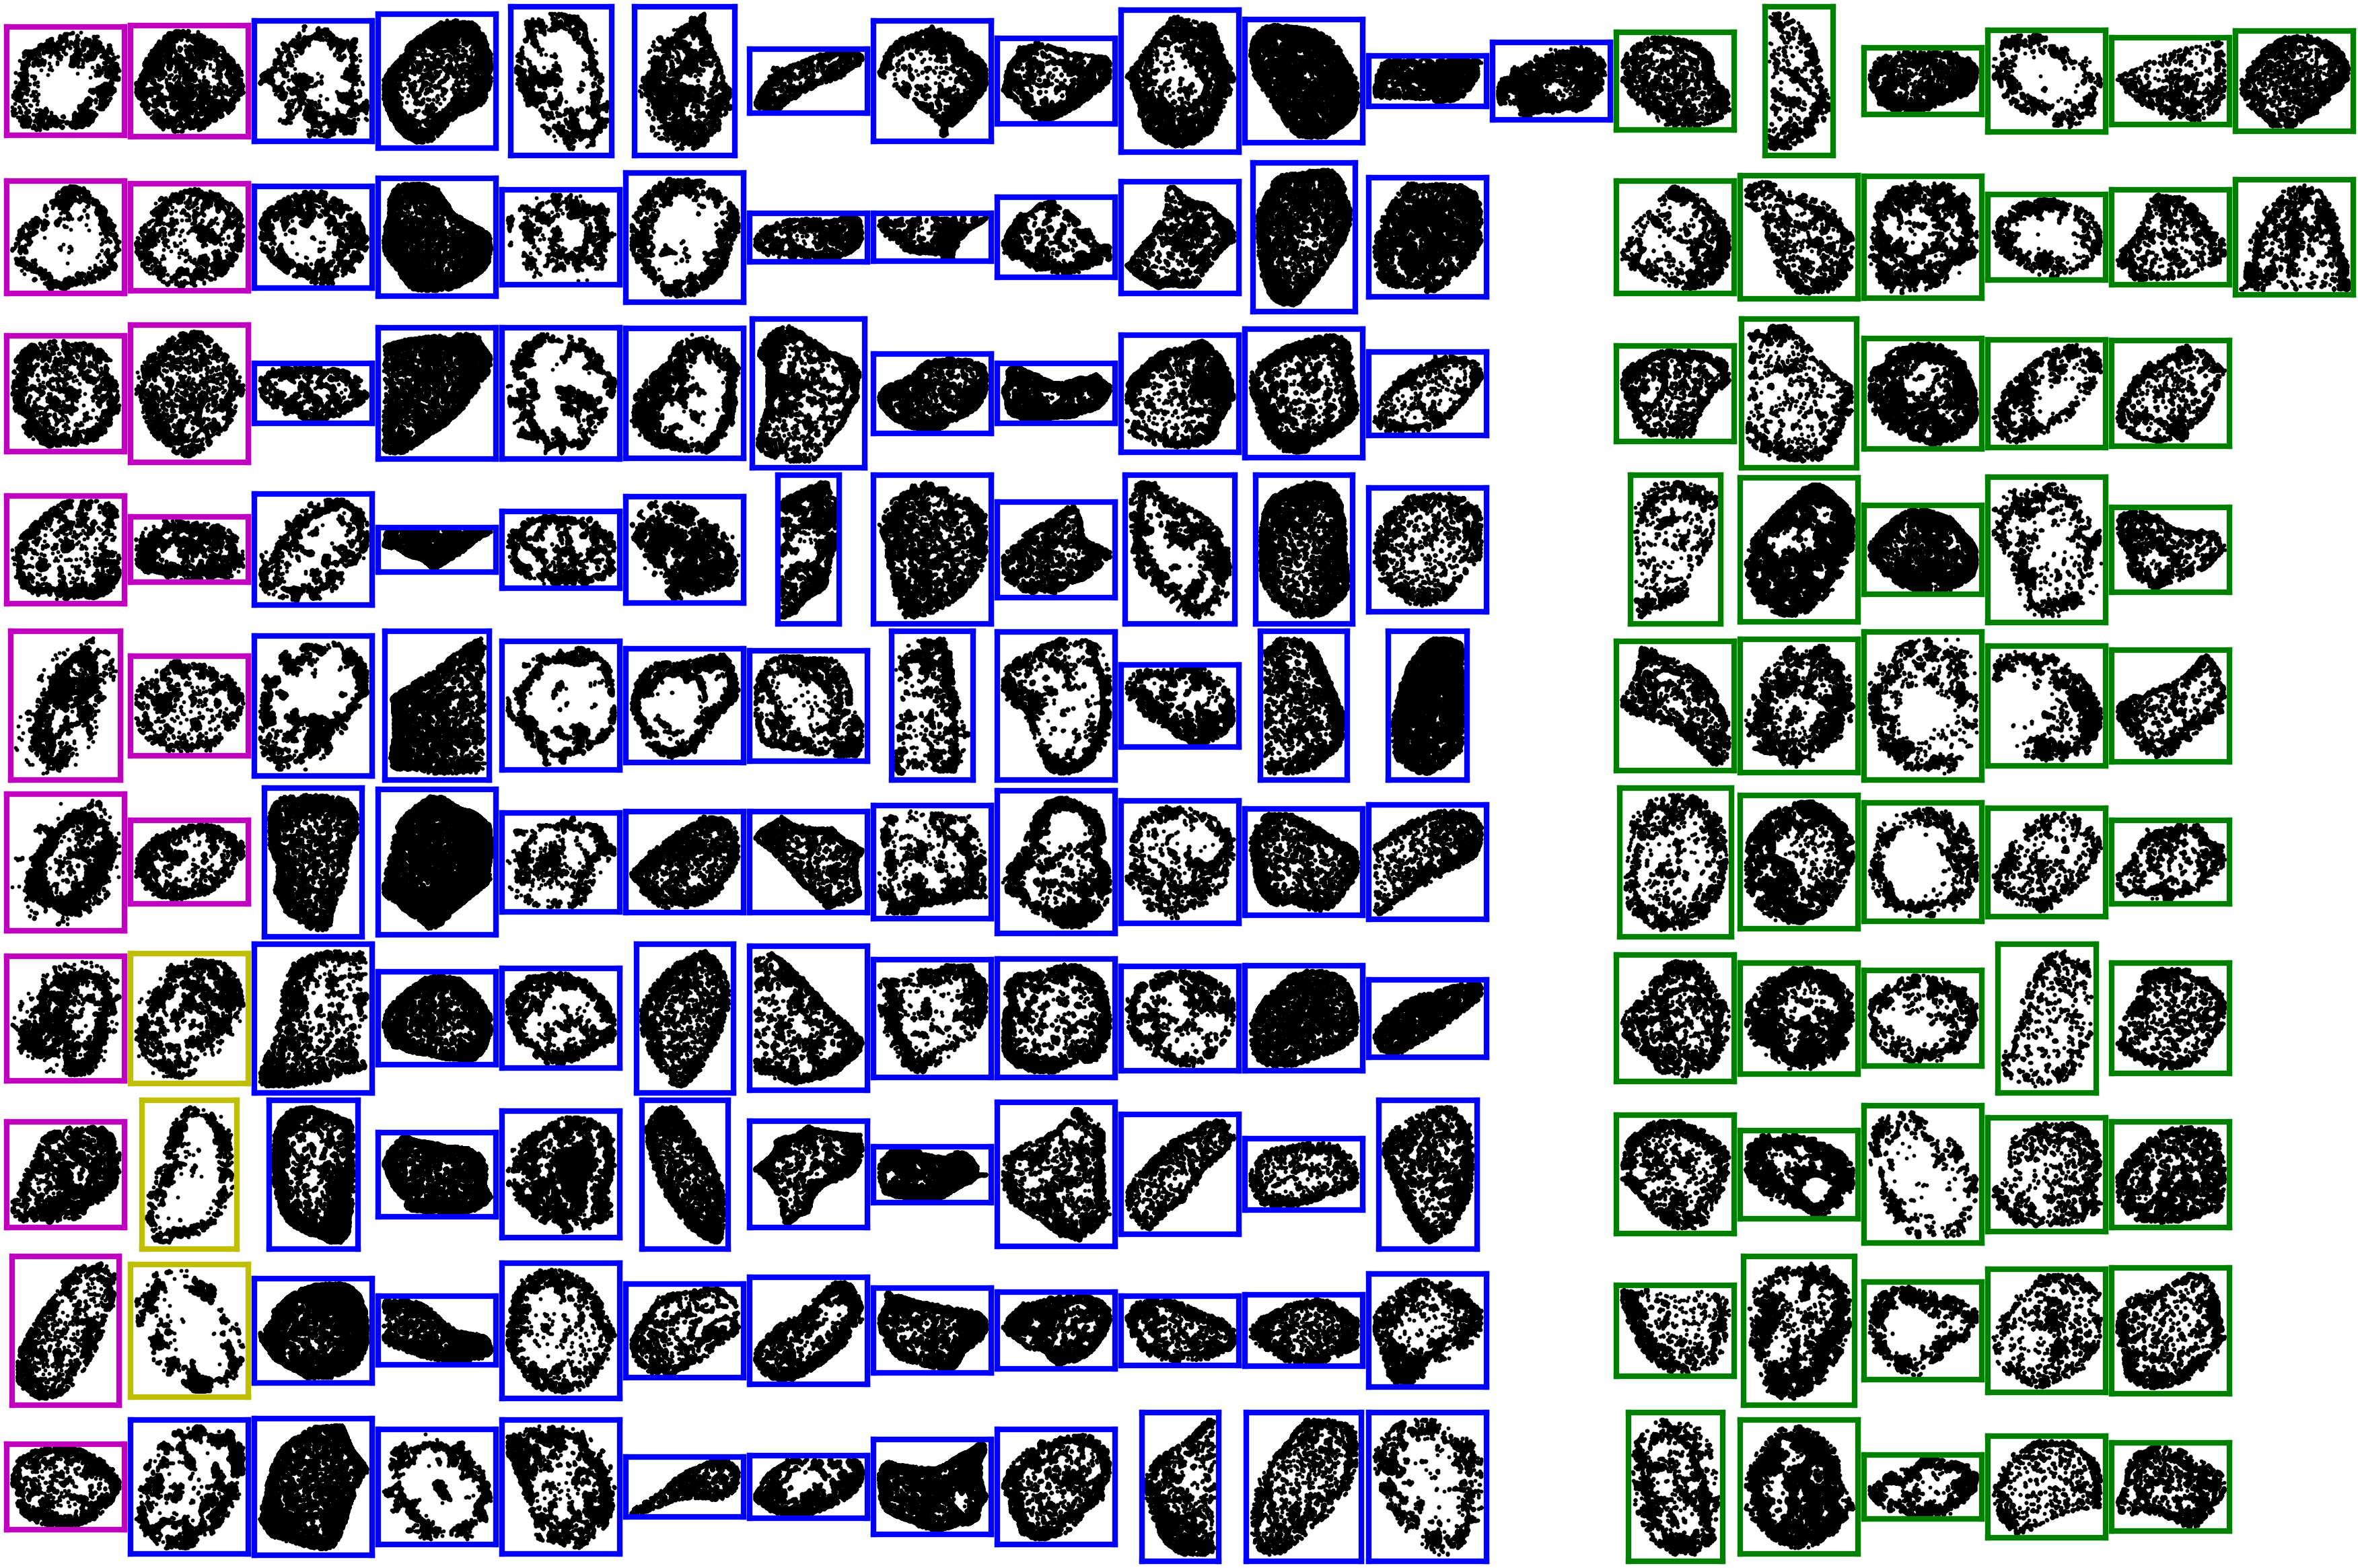

In [9]:
file_map = pl.read_csv("../config/linked_files.csv")
plt.close("all")
%matplotlib inline
fig, axs = plt.subplots(10, 19, figsize=(45,30))

n_0 = 0
n_1 = 0

files_sorted = []
best_rs = []

for file in files:

    # load memb and cell item
    item = datastruc.item(None, None, None, None, None)
    item.load_from_parquet(os.path.join(input_folder, file))
    df = item.df
    #print("Number of locs: ", len(df))
    #print("GT label: ", item.gt_label)

    name = item.name
    start_idx = name.find("_cell_")
    pid = name[0:start_idx]
    map = file_map.filter(pl.col("patient") == pid)

    best_r = map["best_r"].to_numpy()[0]

    best_rs.append(best_r)
    files_sorted.append(file)

# Sorting both lists based on list1
best_rs, files_sorted = zip(*sorted(zip(best_rs, files_sorted), reverse=True))

# Convert back to lists
files_sorted = list(files_sorted)

for file in files_sorted:

    # load memb and cell item
    item = datastruc.item(None, None, None, None, None)
    item.load_from_parquet(os.path.join(input_folder, file))
    df = item.df
    #print("Number of locs: ", len(df))
    #print("GT label: ", item.gt_label)

    name = item.name
    start_idx = name.find("_cell_")
    pid = name[0:start_idx]
    map = file_map.filter(pl.col("patient") == pid)

    best_r = map["best_r"].to_numpy()[0]

    if item.gt_label == 0:
        # folders
        counter_0 = n_0 % 10
        counter_1 = n_0 // 10
        plot_cell(df, axs[counter_0, counter_1], label=item.gt_label, best_r=best_r)
        n_0 += 1
    
    if item.gt_label == 1:
        # folders
        counter_0 = n_1 % 10
        counter_1 = 13 + n_1 // 10
        plot_cell(df, axs[counter_0, counter_1], label=item.gt_label, best_r=best_r)
        n_1 += 1

# delete empty axes - custom to this plot
fig.delaxes(axs[1][12])
fig.delaxes(axs[2][12])
fig.delaxes(axs[3][12])
fig.delaxes(axs[4][12])
fig.delaxes(axs[5][12])
fig.delaxes(axs[6][12])
fig.delaxes(axs[7][12])
fig.delaxes(axs[8][12])
fig.delaxes(axs[9][12])

fig.delaxes(axs[2][18])
fig.delaxes(axs[3][18])
fig.delaxes(axs[4][18])
fig.delaxes(axs[5][18])
fig.delaxes(axs[6][18])
fig.delaxes(axs[7][18])
fig.delaxes(axs[8][18])
fig.delaxes(axs[9][18])

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.gca().invert_yaxis()
plt.show()
#plt.savefig("FILEPATH.png", dpi=600, bbox_inches="tight")
    

## Visualise individual cell [raw data]

File:  PAT1_cell_1.parquet
GT label:  no_response


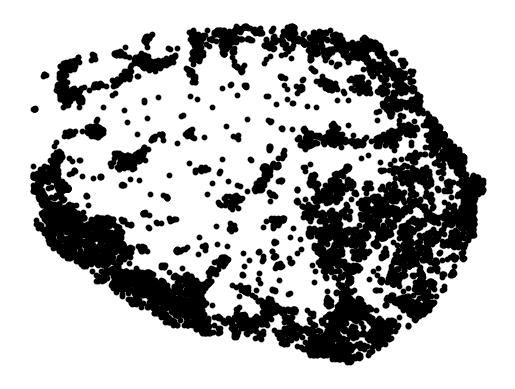

In [12]:
cell_num = 1
target_file = f"PAT1_cell_{cell_num}.parquet"

for file in files:

    if file == target_file:
        item = datastruc.item(None, None, None, None, None)
        item.load_from_parquet(os.path.join(input_folder, file))
        print("File: ", file)
        print("GT label: ", item.gt_label_map[item.gt_label])
        df = item.df
        plt.tick_params(left = False, labelleft=False, bottom = False, labelbottom=False)
        plt.axis("off")
        x = df[["x"]] - df[["x"]].min().item()
        y = df[["y"]] - df[["y"]].min().item()
        y = [-y for y in y]
        plt.scatter(x, y, c='k', s=10)
        #plt.savefig(f"example_cell_response_{item.gt_label}.svg")
        plt.show()


## Visualise individual cell [processed data]

In [107]:
def find_graph_path(project_directory, file_name, file_folder):
    """Visualise raw data
    
    Args:
        project_directory (string): Location of project directory
        file_name (string) : Name of file to image
        file_folder (string) : Which folder the file is in"""
    
    train_file_map_path = os.path.join(project_directory, f"{file_folder}/train/file_map.csv")
    val_file_map_path = os.path.join(project_directory, f"{file_folder}/val/file_map.csv")
    test_file_map_path = os.path.join(project_directory, f"{file_folder}/test/file_map.csv")
    
    train_file_map = pd.read_csv(train_file_map_path)
    val_file_map = pd.read_csv(val_file_map_path)
    test_file_map = pd.read_csv(test_file_map_path)
    
    train_out = train_file_map[train_file_map["file_name"] == file_name]
    val_out = val_file_map[val_file_map["file_name"] == file_name]
    test_out = test_file_map[test_file_map["file_name"] == file_name]
    
    if len(train_out) > 0:
        folder = "train"
        file_name = train_out["idx"].values[0]
    if len(val_out) > 0:
        folder = "val"
        file_name = val_out["idx"].values[0]
    if len(test_out) > 0:
        folder = "test"
        file_name = test_out["idx"].values[0]
    
    return os.path.join(project_directory, f"{file_folder}/{folder}/{file_name}.pt")

from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import torch
from torch_geometric.utils.convert import to_networkx
import networkx as nx
from networkx.drawing import draw_networkx, draw

### Clustering in processed graph

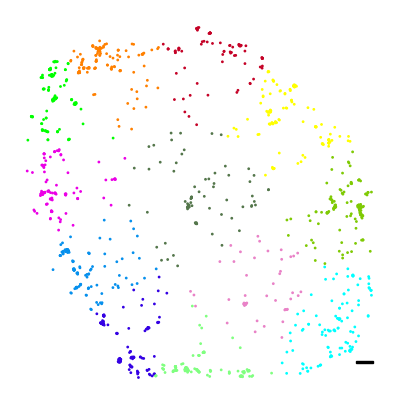

In [109]:
# visualise clustering in processed graph

file_folder = "nn_analysis/N0/processed/fold_0"

colors_grey = ['0.8', (0.0, 1.0, 0.0), (0.9198330167772646, 0.00019544195496590255, 0.9023663764628042), (0.022826063681157582, 0.5658432009989469, 0.9292042754527637), (1.0, 0.5, 0.0), (0.2022271667963922, 0.004776515828955663, 0.892404204324589), (0.3303283202899151, 0.4608491026134133, 0.2941030733894585), (0.5, 1.0, 0.5), (0.7723074963983451, 0.0066115490293984225, 0.15243662980903372), (0.9136952591189091, 0.5104151769385785, 0.7797496184063708), (1.0, 1.0, 0.0), (0.0, 1.0, 1.0), (0.4996633088717094, 0.7906621743682507, 0.01563627319525085)]
cmap_grey = ListedColormap(colors_grey)
colors = [(0.0, 1.0, 0.0), (0.9198330167772646, 0.00019544195496590255, 0.9023663764628042), (0.022826063681157582, 0.5658432009989469, 0.9292042754527637), (1.0, 0.5, 0.0), (0.2022271667963922, 0.004776515828955663, 0.892404204324589), (0.3303283202899151, 0.4608491026134133, 0.2941030733894585), (0.5, 1.0, 0.5), (0.7723074963983451, 0.0066115490293984225, 0.15243662980903372), (0.9136952591189091, 0.5104151769385785, 0.7797496184063708), (1.0, 1.0, 0.0), (0.0, 1.0, 1.0), (0.4996633088717094, 0.7906621743682507, 0.01563627319525085)]
cmap_no_grey = ListedColormap(colors)

fig, ax = plt.subplots(1,1,figsize=(5,5), sharex=True, sharey=True)

#for idx, file_name in enumerate(files):

file_loc = find_graph_path(".", target_file.rstrip(".parquet"), file_folder)
# raw file
processed_file = torch.load(file_loc, weights_only=False)
c = processed_file.edge_index_dict["locs", "in", "clusters"][1].cpu().numpy()
processed_file = processed_file.pos_dict['locs'].cpu().numpy()
x = processed_file[:,0]
y = processed_file[:,1]
    # center points
x_mean = np.mean(x)
y_mean = np.mean(y)
x = x - x_mean 
y = y - y_mean
ax.set_aspect('equal', adjustable='box')

if np.min(c) == -1:
    cmap = cmap_grey
else:
    cmap = cmap_no_grey
y = [-y for y in y]
ax.scatter(x, y, s=1, c=c, cmap=cmap)
ax.axis('off')
scalebar = AnchoredSizeBar(ax.transData,
                            0.1, '', 'lower right', 
                            pad=1,
                            color='k',
                            frameon=False,
                            size_vertical=0.01)

ax.add_artist(scalebar)
   
#output_path = os.path.join(project_directory, "output/processed_clusters.svg") 
#plt.subplots_adjust(wspace=0, hspace=0)
#plt.savefig(output_path, transparent=True, bbox_inches="tight", pad_inches=0)


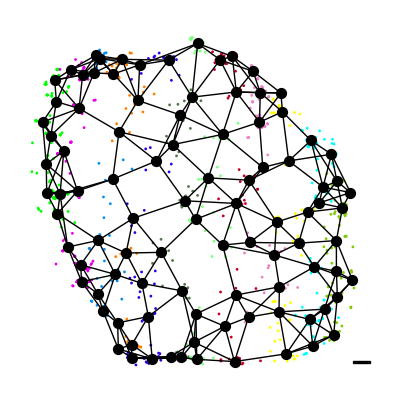

In [113]:
# visualise overlaid subgraph using matplotlib

#dataitems = torch.load(os.path.join(project_directory, "output/subgraphx_dataitems_rollout_100.pt"))
#node_imps = torch.load(os.path.join(project_directory, "output/subgraphx_nodeimps_rollout_100.pt"))
from torch_geometric.data import Data

file_folder = "nn_analysis/N7/processed/fold_0"

fig, ax = plt.subplots(1,1,figsize=(5,5), sharex=True, sharey=True)
    
file_loc = find_graph_path(".", target_file.rstrip(".parquet"), file_folder)

# raw file
processed_file_load = torch.load(file_loc, weights_only=False)
processed_file = processed_file_load.pos_dict['locs'].cpu().numpy()
x = processed_file[:,0]
y = processed_file[:,1]
 # center points
x_mean = np.mean(x)
y_mean = np.mean(y)
x = x - x_mean 
y = y - y_mean
ax.set_aspect('equal', adjustable='box')
c = '0.8'
c = processed_file_load.edge_index_dict["locs", "in", "clusters"][1].cpu().numpy()
y = [-y for y in y]
ax.scatter(x, y, s=1, c=c, cmap=cmap)
#ax[idx].axis('off')
scalebar = AnchoredSizeBar(ax.transData,
                           0.1, '', 'lower right', 
                           pad=1,
                           color='k',
                           frameon=False,
                           size_vertical=0.01)

ax.add_artist(scalebar)
# graph
homogeneous_graph = Data(x=None, edge_index=processed_file_load.edge_index_dict["clusters", "near", "clusters"], pos=processed_file_load.pos_dict["clusters"])
nx_g = to_networkx(homogeneous_graph, to_undirected=True)
nx_g.remove_edges_from(nx.selfloop_edges(nx_g))
pos = homogeneous_graph.pos.cpu().numpy()
node_color = "k"#np.where(node_imps.cpu().numpy(), '#00FF00', 'k')
# center points
pos[:,0] = pos[:,0] - x_mean
pos[:,1] = -(pos[:,1] - y_mean)
#pos=np.flip(pos, axis= 1)
#pos[:,1] = [-pos for pos in pos]
draw(nx_g, pos=pos, ax=ax, node_color=node_color, node_size=50)

output_path = "new_cell_with_k_96_clusters.svg"#os.path.join(project_directory, "output", "combined" + '_subgraphx_s_1.svg') 
plt.subplots_adjust(wspace=0, hspace=0)
plt.savefig(output_path, transparent=True, bbox_inches="tight", pad_inches=0)


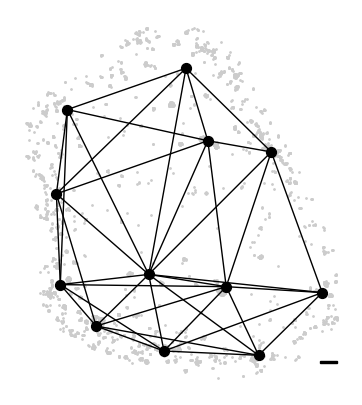

In [31]:
# visualise overlaid subgraph using matplotlib

#dataitems = torch.load(os.path.join(project_directory, "output/subgraphx_dataitems_rollout_100.pt"))
#node_imps = torch.load(os.path.join(project_directory, "output/subgraphx_nodeimps_rollout_100.pt"))
from torch_geometric.data import Data

file_folder = "nn_analysis/N0/processed/fold_0"

fig, ax = plt.subplots(1,1,figsize=(5,5), sharex=True, sharey=True)
    
file_loc = find_graph_path(".", target_file.rstrip(".parquet"), file_folder)

# raw file
processed_file_load = torch.load(file_loc, weights_only=False)
processed_file = processed_file_load.pos_dict['locs'].cpu().numpy()
x = processed_file[:,0]
y = processed_file[:,1]
 # center points
x_mean = np.mean(x)
y_mean = np.mean(y)
x = x - x_mean 
y = y - y_mean
ax.set_aspect('equal', adjustable='box')
ax.scatter(y, x, s=1, c='0.8')
#ax[idx].axis('off')
scalebar = AnchoredSizeBar(ax.transData,
                           0.1, '', 'lower right', 
                           pad=1,
                           color='k',
                           frameon=False,
                           size_vertical=0.01)

ax.add_artist(scalebar)
# graph
homogeneous_graph = Data(x=None, edge_index=processed_file_load.edge_index_dict["clusters", "near", "clusters"], pos=processed_file_load.pos_dict["clusters"])
nx_g = to_networkx(homogeneous_graph, to_undirected=True)
nx_g.remove_edges_from(nx.selfloop_edges(nx_g))
pos = homogeneous_graph.pos.cpu().numpy()
node_color = "k"#np.where(node_imps.cpu().numpy(), '#00FF00', 'k')
# center points
pos[:,0] = pos[:,0] - x_mean
pos[:,1] = pos[:,1] - y_mean
draw(nx_g, pos=np.flip(pos, axis= 1), ax=ax, node_color=node_color, node_size=50)

#output_path = os.path.join(project_directory, "output", "combined" + '_subgraphx_s_1.svg') 
#plt.subplots_adjust(wspace=0, hspace=0)
#plt.savefig(output_path, transparent=True, bbox_inches="tight", pad_inches=0)
